✓ Successfully generated fixed_wc_0.001_varying_N.png and fixed_wc_0.001_varying_N.pdf


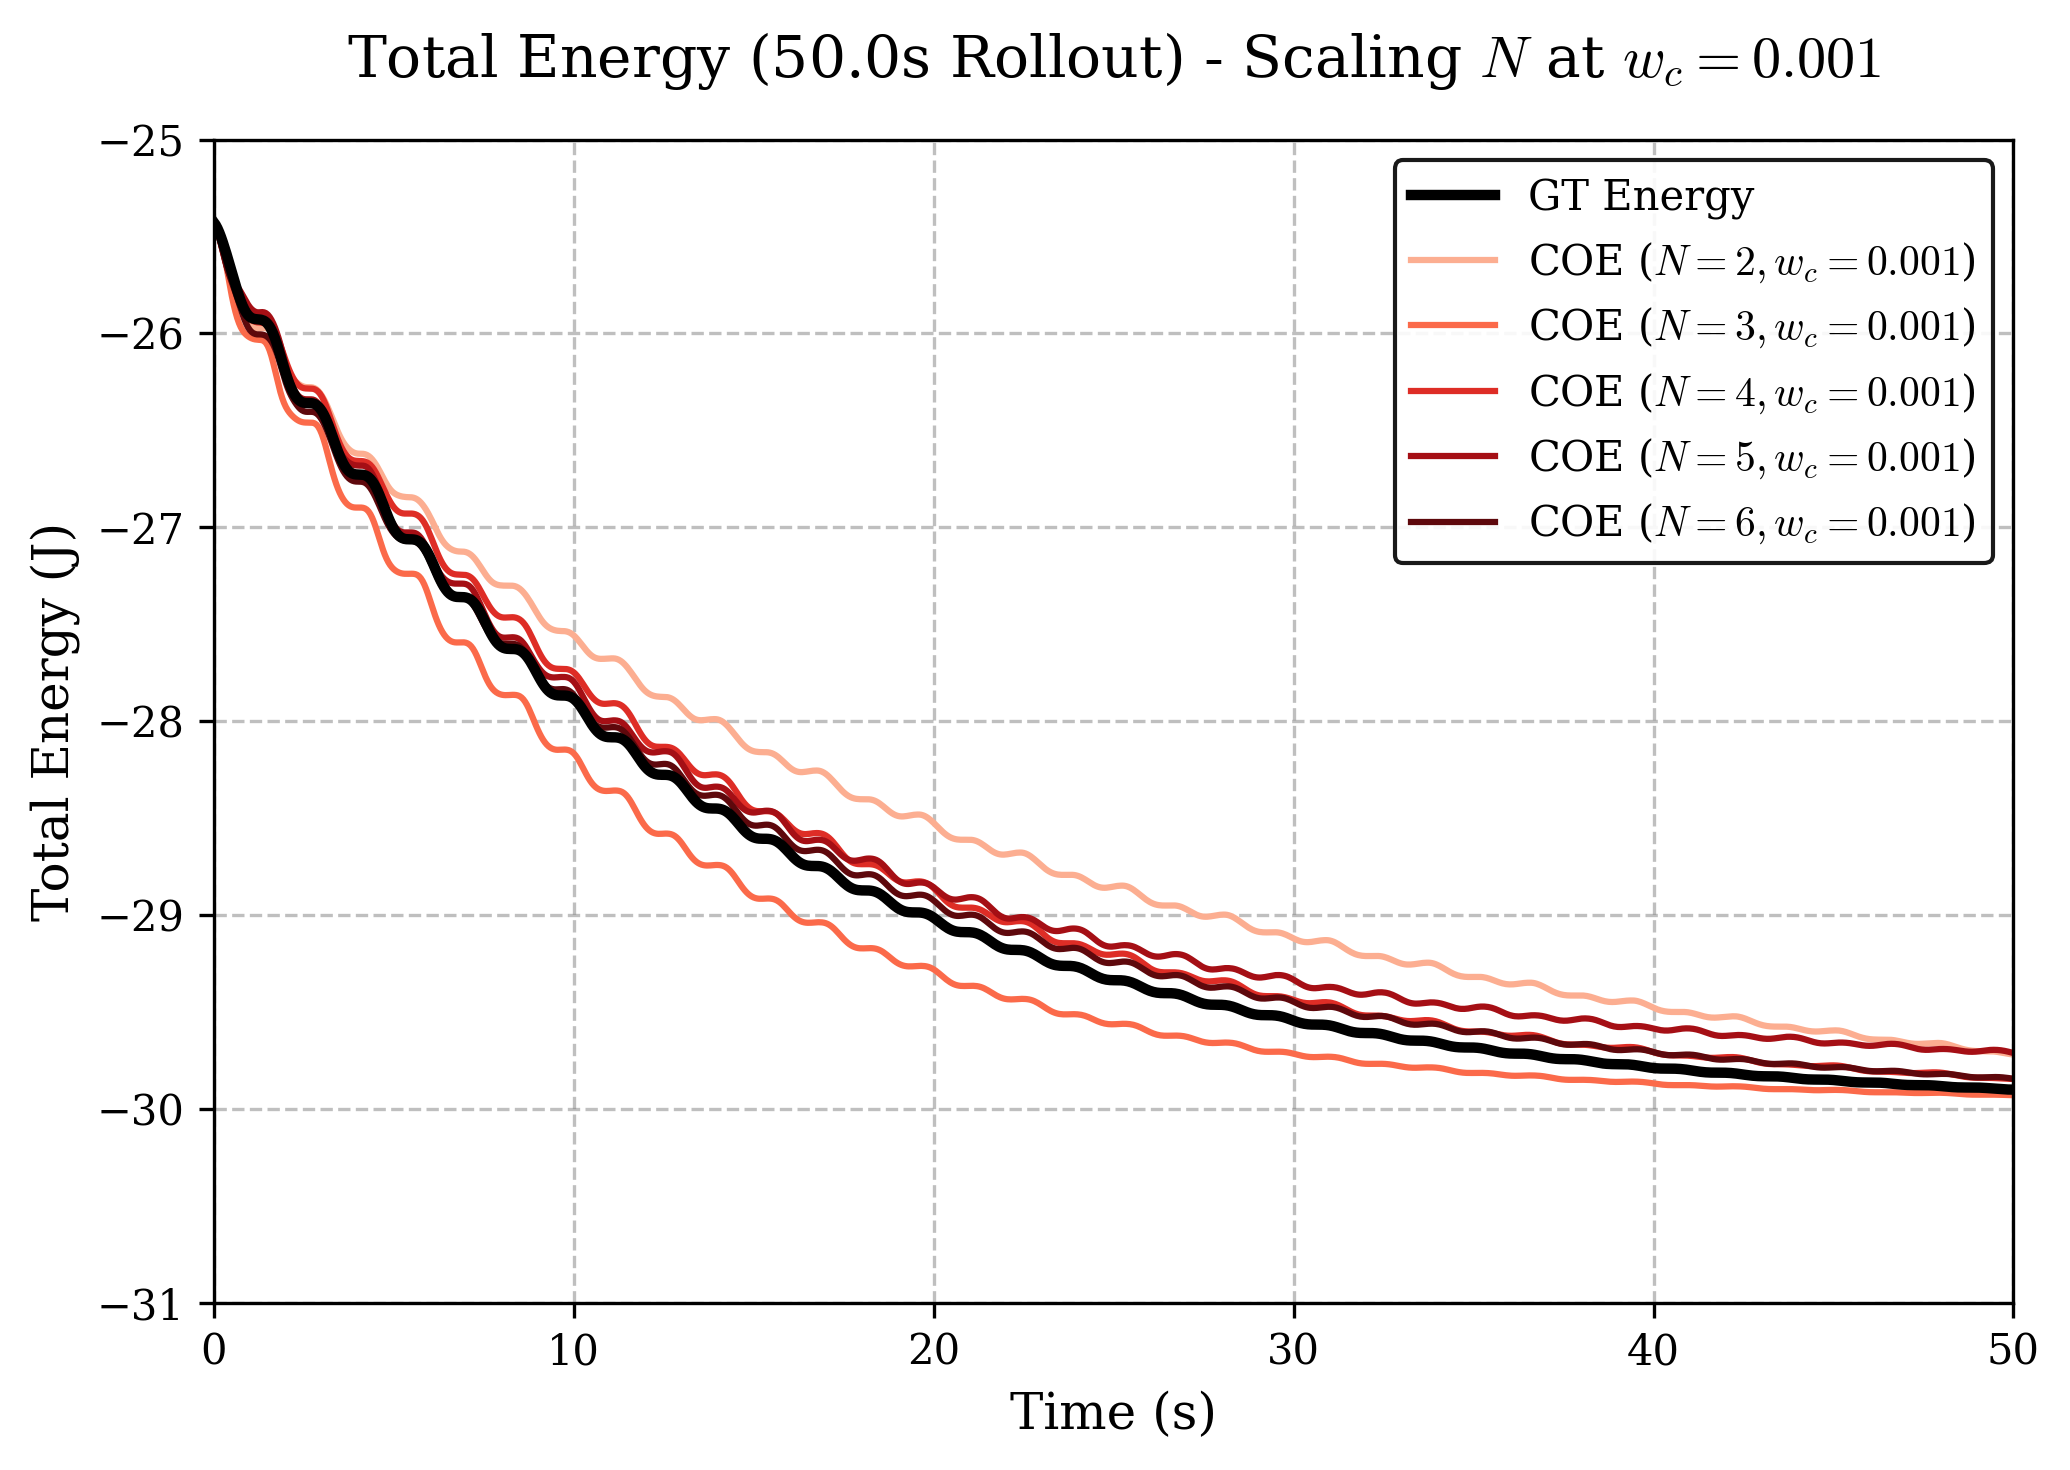

✓ Successfully generated fixed_wc_0.01_varying_N.png and fixed_wc_0.01_varying_N.pdf


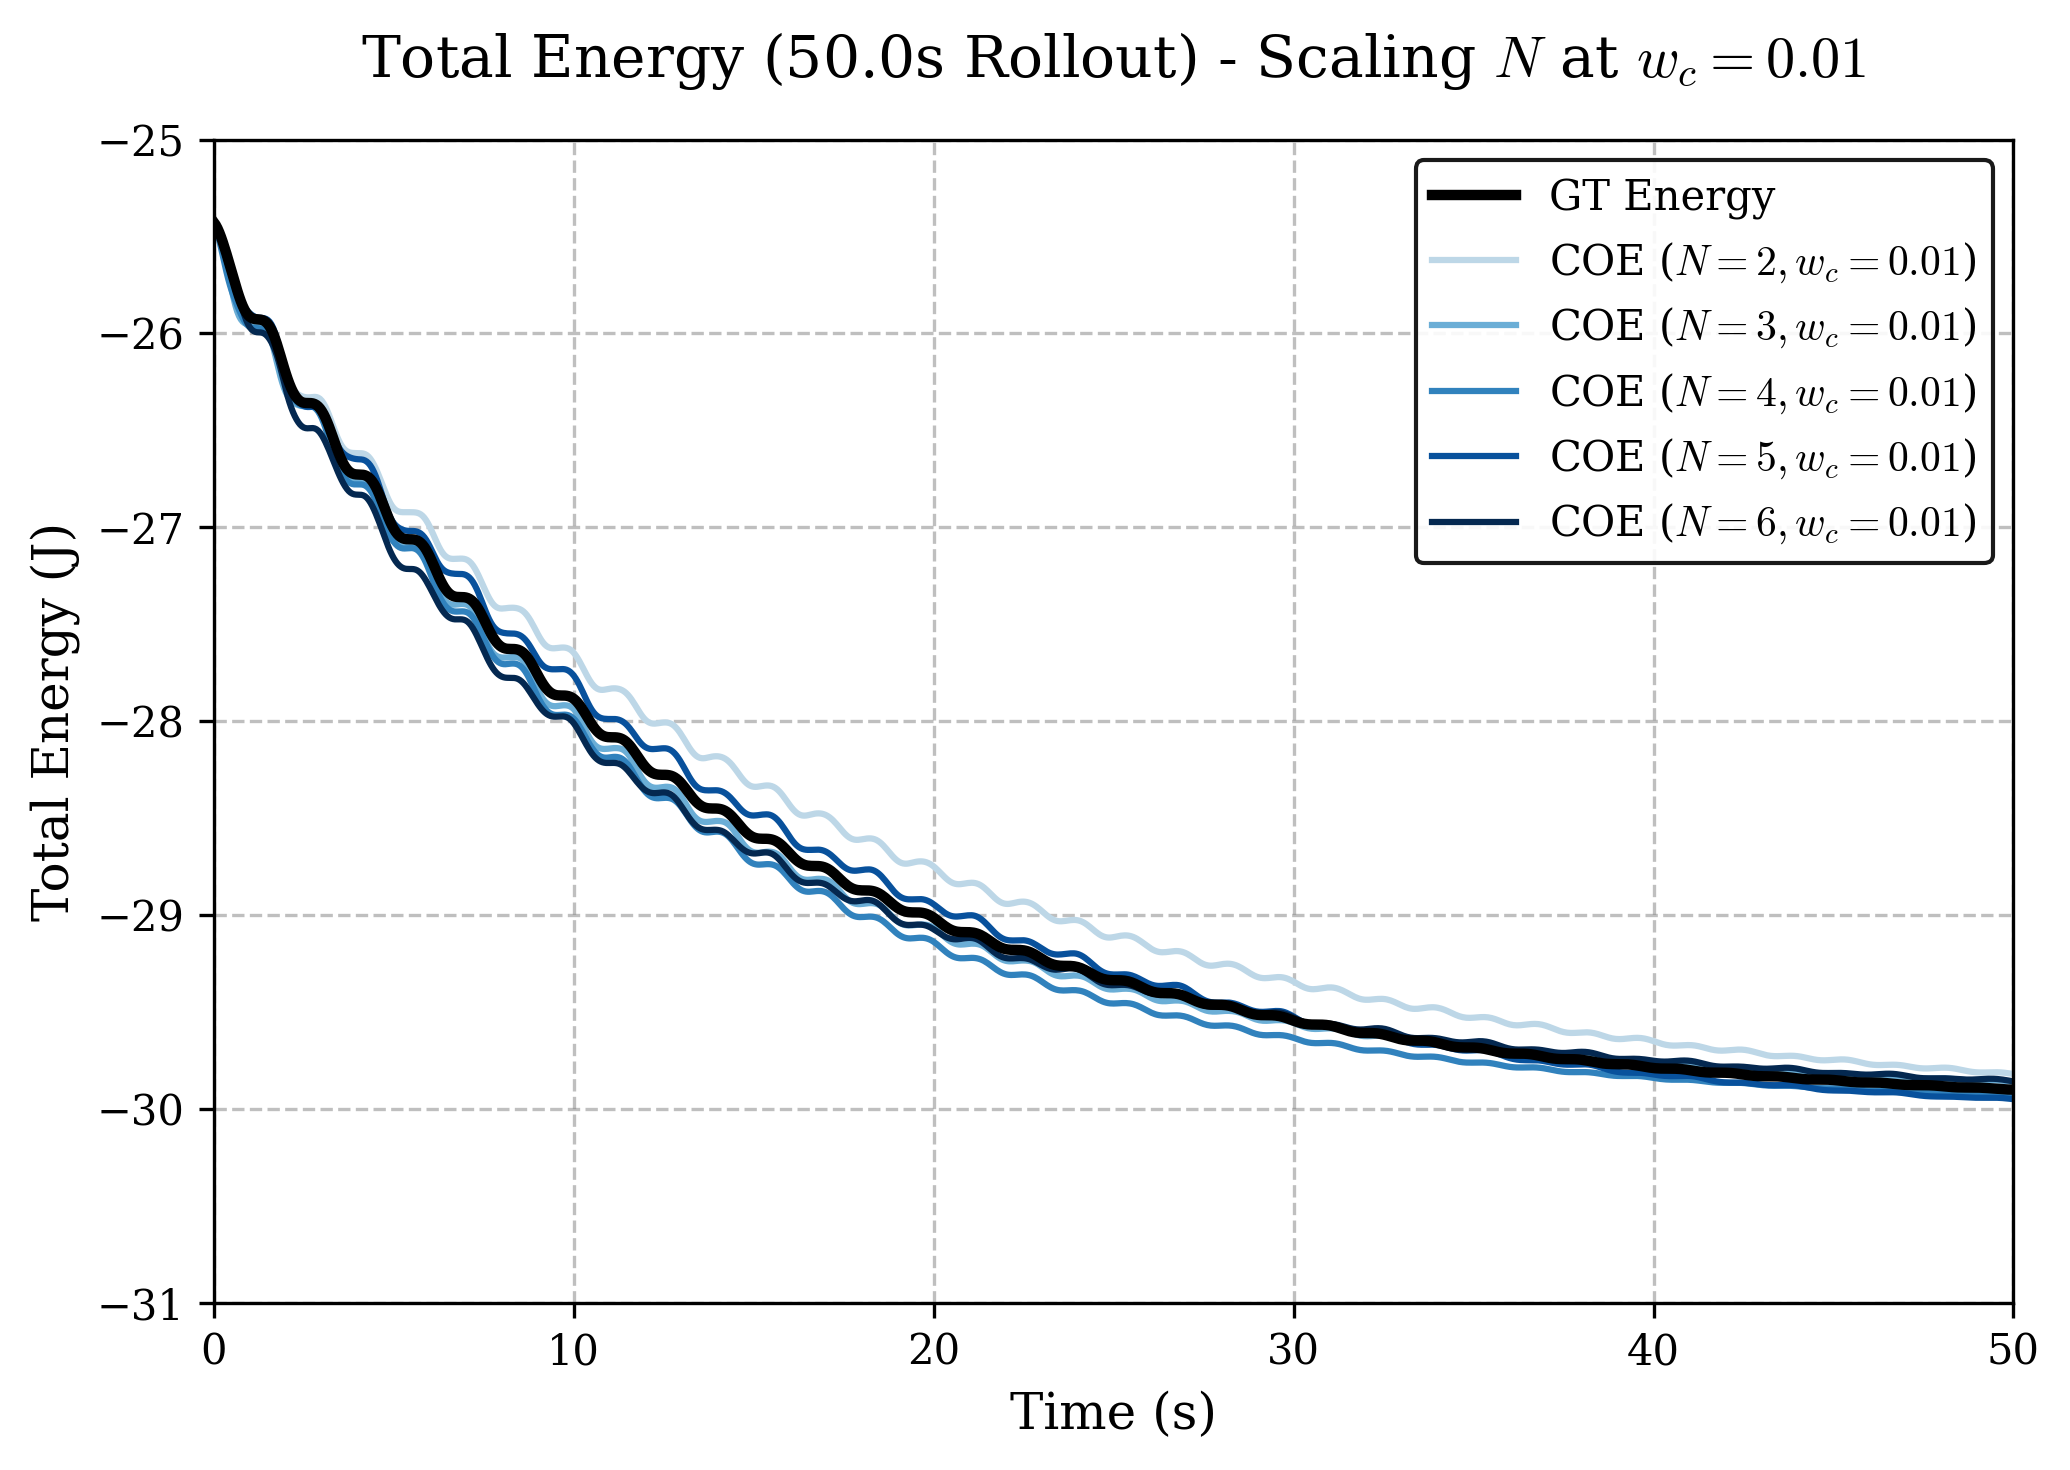

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# =============================================================================
# ENVIRONMENT-SAFE PUBLICATION FORMATTING
# Uses built-in Computer Modern to avoid "latex not found" errors
# =============================================================================
mpl.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'serif'],
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# =============================================================================
# 1. CONFIGURATION
# =============================================================================
w_c_values = ['0.001', '0.01']
N_values = [2, 3, 4, 5, 6]

# Define distinct sequential colormaps for the two w_c settings (5 colors each)
palettes = {
    '0.001': ['#FCAE91', '#FB6A4A', '#DE2D26', '#A50F15', '#5E080C'], # Sequential Reds
    '0.01':  ['#BDD7E7', '#6BAED6', '#3182BD', '#08519C', '#042850']  # Sequential Blues
}

# =============================================================================
# 2. AUTOMATED PLOT GENERATION
# =============================================================================
for wc in w_c_values:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

    # Safely extract Ground Truth and Time axis from the first available file
    GT_energy = None
    time = None
    for N in N_values:
        fname = f"long_energy_ts_{N}_wc={wc}.npy"
        if os.path.exists(fname):
            data = np.load(fname, allow_pickle=True).item()
            time = data['time']
            GT_energy = data['energy_gt']
            break

    if GT_energy is not None:
        # Plot Ground Truth (Thick Black Line)
        ax.plot(time, GT_energy, color='black', linewidth=2.5, label='GT Energy', zorder=5)
    else:
        print(f"--- Skipping wc={wc}: No valid .npy files found. ---")
        continue

    # Plot each Ensemble Size (N) variation
    colors = palettes[wc]
    for i, N in enumerate(N_values):
        file_name = f"long_energy_ts_{N}_wc={wc}.npy"

        if os.path.exists(file_name):
            data = np.load(file_name, allow_pickle=True).item()
            E_pred = data['energy_pred']
            ax.plot(time, E_pred, color=colors[i], linewidth=1.5,
                    label=rf'COE ($N={N}, w_c={wc}$)')
        else:
            print(f"Notice: Missing file '{file_name}', skipping this line.")

    # Formatting
    ax.set_title(rf'Total Energy (50.0s Rollout) - Scaling $N$ at $w_c={wc}$', fontsize=14, pad=15)
    ax.set_xlabel(r'Time (s)')
    ax.set_ylabel(r'Total Energy (J)')
    ax.set_xlim([0, 50])
    ax.set_ylim([-31, -25])

    # Grid and Legend
    ax.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.legend(loc='upper right', framealpha=0.9, edgecolor='black')

    # Save Figures dynamically based on the fixed w_c
    plt.tight_layout()
    png_name = f'fixed_wc_{wc}_varying_N.png'
    pdf_name = f'fixed_wc_{wc}_varying_N.pdf'

    plt.savefig(png_name, bbox_inches='tight')
    plt.savefig(pdf_name, bbox_inches='tight')

    print(f"✓ Successfully generated {png_name} and {pdf_name}")
    plt.show()